# Bluesky scan with T8 and with tiled



# Preamble

## Preamble for Jupyter

In [3]:
if 0:  # if True, display full output in Jupyter, not only last result
    from IPython.core.interactiveshell import InteractiveShell

    InteractiveShell.ast_node_interactivity = "all"  # type: ignore

from IPython.display import (
    display,  # noqa: F401
    Math,  # noqa: F401
)  # to display results in Jupyter, and to print in Latex format (not only for sympy)

## Example display Latex
# display(Math('\\pi =' + f'{np.pi:.6f}'))
# display(Math('\\sin(\\theta)'))


## Preamble Main Libraries and a few usefull constants

In [4]:
import numpy as np
import pandas as pd

import sys  # noqa: F401
import os  # noqa: F401

# sys.path.append(os.environ['USERPROFILE'] + '\\workspace\\python\\libs\\wgTools')
# import wgutils as wgu
from scipy import constants

deg2rad = np.deg2rad(1)
rad2deg = np.rad2deg(1)
eps = np.finfo(np.float64).eps
hc = constants.value("inverse meter-electron volt relationship")

## Preamble for Matplotlib


In [ ]:
# interative inline figures for JupyterLab need to be set by IPython magic commands
# to check all the matplotlib backends, run
%matplotlib --list
# for vscode you want to use widget
%matplotlib qt
# if you export this code to a .py file, you need to run the line below for iterative ploting in ipython
# get_ipython().run_line_magic('matplotlib', '--list')
# interative inline figures for JupyterLab
# get_ipython().run_line_magic('matplotlib', 'qt5')
# for colab you may need to install ipympl
# !pip install ipympl
# Then run the magic
# %matplotlib ipympl

import matplotlib.pyplot as plt

plt.style.use("default")

params = {
    "font.size": 10,
    "legend.fontsize": "small",
    "font.family": "serif",
    "figure.facecolor": "white",
    "axes.grid": True,
    "figure.autolayout": True,
    "axes.grid.axis": "both",
    "mathtext.fontset": "stix",
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.figsize": (6, 5),
    "image.origin": "lower",
    "image.interpolation": "none",
    "image.cmap": "magma",
    "lines.marker": "o",
    "lines.linestyle": "-",
}

plt.rcParams.update(params)

Available matplotlib backends: ['agg', 'auto', 'cairo', 'gtk3', 'gtk3agg', 'gtk3cairo', 'gtk4', 'gtk4agg', 'gtk4cairo', 'inline', 'ipympl', 'macosx', 'nbagg', 'notebook', 'osx', 'pdf', 'pgf', 'ps', 'qt', 'qt5', 'qt5agg', 'qt5cairo', 'qt6', 'qtagg', 'qtcairo', 'svg', 'template', 'tk', 'tkagg', 'tkcairo', 'webagg', 'widget', 'wx', 'wx', 'wxagg', 'wxcairo']


## Preamble Bluesky, LabJack and Tiled

In [6]:
# %% Bluesky and Ophyd imports
from bluesky import RunEngine  # type: ignore
from bluesky.plans import count, scan  # type: ignore  # noqa: F401
from bluesky.callbacks.best_effort import BestEffortCallback
from ophyd.sim import motor  # type: ignore

In [7]:
## Preamble LabJack
from ophyd_labjack_t8 import LabJackT8

In [8]:
# %% Databroker and Tiled imports
from tiled.server import SimpleTiledServer
from tiled.client import from_uri
from bluesky.callbacks.tiled_writer import TiledWriter

## Preamble Plotly

In [9]:
import plotly.graph_objs as go
import plotly.colors
import itertools

colors_plotly = plotly.colors.DEFAULT_PLOTLY_COLORS
# C1, C2, Ci,... equivalent. use colors[i], or colors[i % len(colors)] to cycle through them
# Also, use
# color_cycle = itertools.cycle(colors_plotly)
# next(color_cycle) to get the next color in the cycle, and it will start from the beginning again when it reaches the end of the list


def custom_layout(xlabel=None, ylabel=None, title=None, template="seaborn"):
    return go.Layout(
        template=template,  # Set the template
        width=800,  # Set the figure width
        height=600,  # Set the figure height
        font=dict(family="Georgia", size=14, color="#3B3B3B"),  # General font settings
        title=dict(
            text=title,
            font=dict(size=24),
            x=0.5,
            xanchor="center",
        ),
        xaxis_title=dict(text=xlabel, font=dict(size=18)),
        yaxis_title=dict(text=ylabel, font=dict(size=18)),
        xaxis=dict(tickfont=dict(size=16)),  # Set X-axis tick font size
        yaxis=dict(tickfont=dict(size=16)),  # Set Y-axis tick font size
    )


# initialize figures with something like
# plotly_fig = go.Figure(layout=custom_layout("Frequency [Hz]", "Amplitude [Volts]", fname))


## Local Functions

In [10]:
def get_unique_fname(base_name, extension="png", verbose=True):
    index = 0
    # check if directory exists, if not create it
    if not os.path.exists(os.path.dirname(base_name)):
        os.makedirs(os.path.dirname(base_name))
    while os.path.exists(f"{base_name}_{index:02d}.{extension}"):
        index += 1
    if verbose:
        print(f"# unique filename: {base_name}_{index:02d}.{extension}")
    return f"{base_name}_{index:02d}.{extension}"

# Setup Script Flags

In [11]:
save_plot = False
close_connections_at_end = False

# Setup Hardware

In [12]:
# %% Initialize LabJAck Hardware

print("[SETUP HW] Initializing LabJack T8...")
try:
    t8 = LabJackT8(
        name="t8", channels=[0, 1, 2, 4], act_time=1.0, sample_rate=1000.0, verbose=True, enable_waveforms=True
    )
    print("[SETUP HW] LabJack T8 initialized.")
    print("[SETUP HW] info:", t8.handle_info)
except Exception as e:
    print(f"[ERROR] Failed to initialize LabJack T8: {e}")
    print("***STOPPING EXECUTION*** Please check the LabJack connection and try again.")
    exit(1)

[SETUP HW] Initializing LabJack T8...
[STATUS] Succesfully Connected to LabJack T8
[INFO] Connected Device: 8, Connection: 1, Serial: 480011020, IP: 0, Port: 0

[SETUP HW] LabJack T8 initialized.
[SETUP HW] info: (8, 1, 480011020, 0, 0, 512)


In [13]:
# %%
# Initialize Bluesky
print("[SETUP ACQUISITION] Initializing RunEngine and BestEffortCallback...")
RE = RunEngine({})
print("[SETUP ACQUISITION] Bluesky RunEngine STARTED. State: ", RE.state)

for key, val in RE.md["versions"].items():
    print(f"[SETUP ACQUISITION] {key} version {val}")

RE.md["any metadata you want to add"] = "example value"

[SETUP ACQUISITION] Initializing RunEngine and BestEffortCallback...
[SETUP ACQUISITION] Bluesky RunEngine STARTED. State:  idle
[SETUP ACQUISITION] ophyd version 1.11.0
[SETUP ACQUISITION] bluesky version 1.14.6


In [14]:
# %% Additional Bluesky settings and subscriptions
# Link the BestEffortCallback for real-time visualization (optional but recommended)
RE.subscribe(BestEffortCallback())  # type: ignore
print("[SETUP ACQUISITION] BestEffortCallback subscribed to RunEngine.")
# Link the internal saver
RE.subscribe(t8.csv_saver)  # (un)comment this line to enable/disable internal CSV saving
print("[SETUP ACQUISITION] RunEngine and BestEffortCallback initialized.")

[SETUP ACQUISITION] BestEffortCallback subscribed to RunEngine.
[SETUP ACQUISITION] RunEngine and BestEffortCallback initialized.


In [15]:
# %% Initialize local Tiled server and client
print("[DATASERVER] Initializing local Tiled server and subscribing to RunEngine...")
save_path = "./tiled_labjack_data"
tiled_server = SimpleTiledServer(readable_storage=[save_path])  # type: ignore
tiled_client = from_uri(tiled_server.uri)
tw = TiledWriter(tiled_client)
RE.subscribe(tw)
print("[DATASERVER] Local Tiled server and TiledWriter initialized and subscribed to RunEngine.")

[DATASERVER] Initializing local Tiled server and subscribing to RunEngine...


Tiled version 0.2.8


[DATASERVER] Local Tiled server and TiledWriter initialized and subscribed to RunEngine.


# Main SCAN

In [16]:
# %% Prepare for plotting, start matplotlib interactive mode, close any existing figures
plt.ion()
plt.close("all")

[ACQUISITION] Acquisition STARTED...


Transient Scan ID: 1     Time: 2026-04-06 17:09:07
Persistent Unique Scan ID: 'd7e8359d-2a47-4784-a341-757f1d11e327'
New stream: 'primary'
+-----------+------------+------------+------------+------------+------------+------------+
|   seq_num |       time |      motor |    t8_ain0 |    t8_ain1 |    t8_ain2 |    t8_ain4 |
+-----------+------------+------------+------------+------------+------------+------------+
|         1 | 17:09:08.7 |     -5.000 |    -11.175 |    -11.795 |     -9.467 |     -9.925 |
|         2 | 17:09:09.9 |     -2.500 |    -11.174 |    -11.792 |     -9.466 |     -9.922 |
|         3 | 17:09:11.1 |      0.000 |    -11.173 |    -11.790 |     -9.466 |     -9.920 |
|         4 | 17:09:12.3 |      2.500 |    -11.171 |    -11.787 |     -9.466 |     -9.917 |
|         5 | 17:09:13.6 |      5.000 |    -11.170 |    -11.785 |     -9.466 |     -9.915 |
+-----------+------------+------------+------------+------------+------------+--------

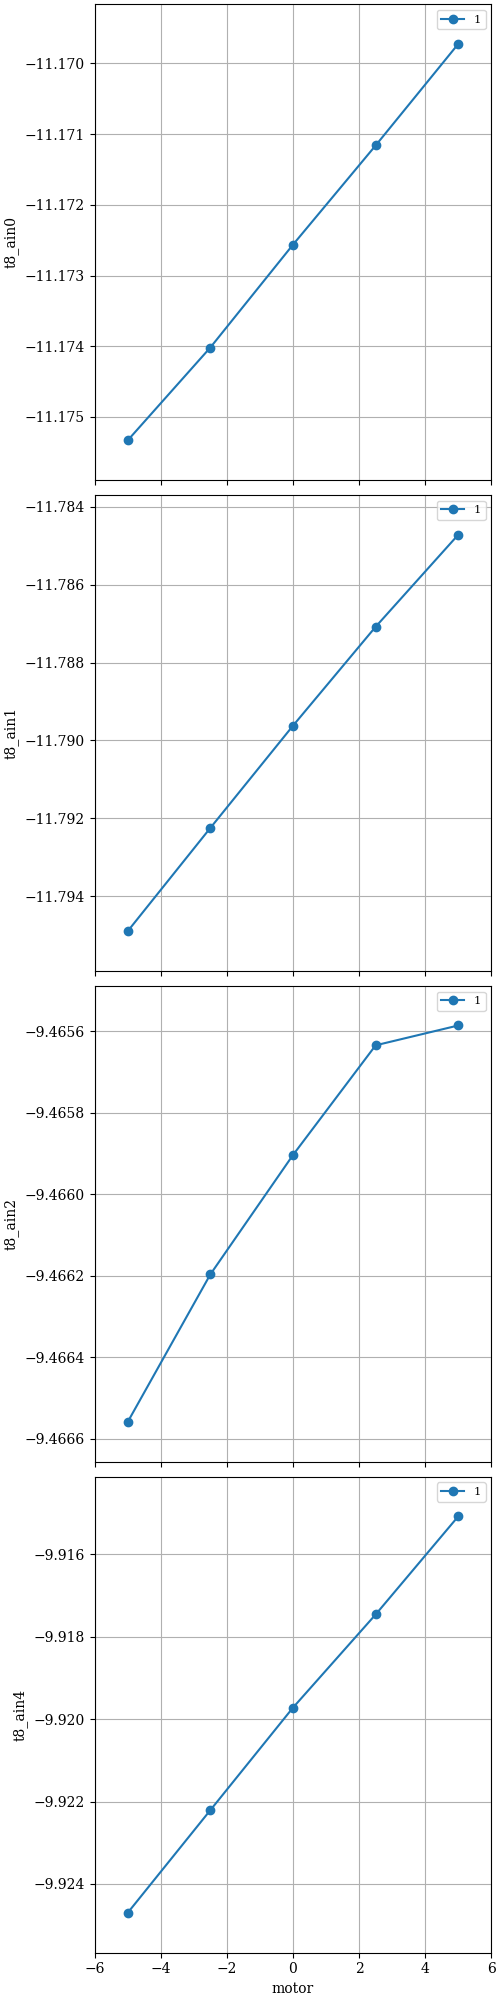

[VISUALIZATION] Close plot to proceed (block=True)...


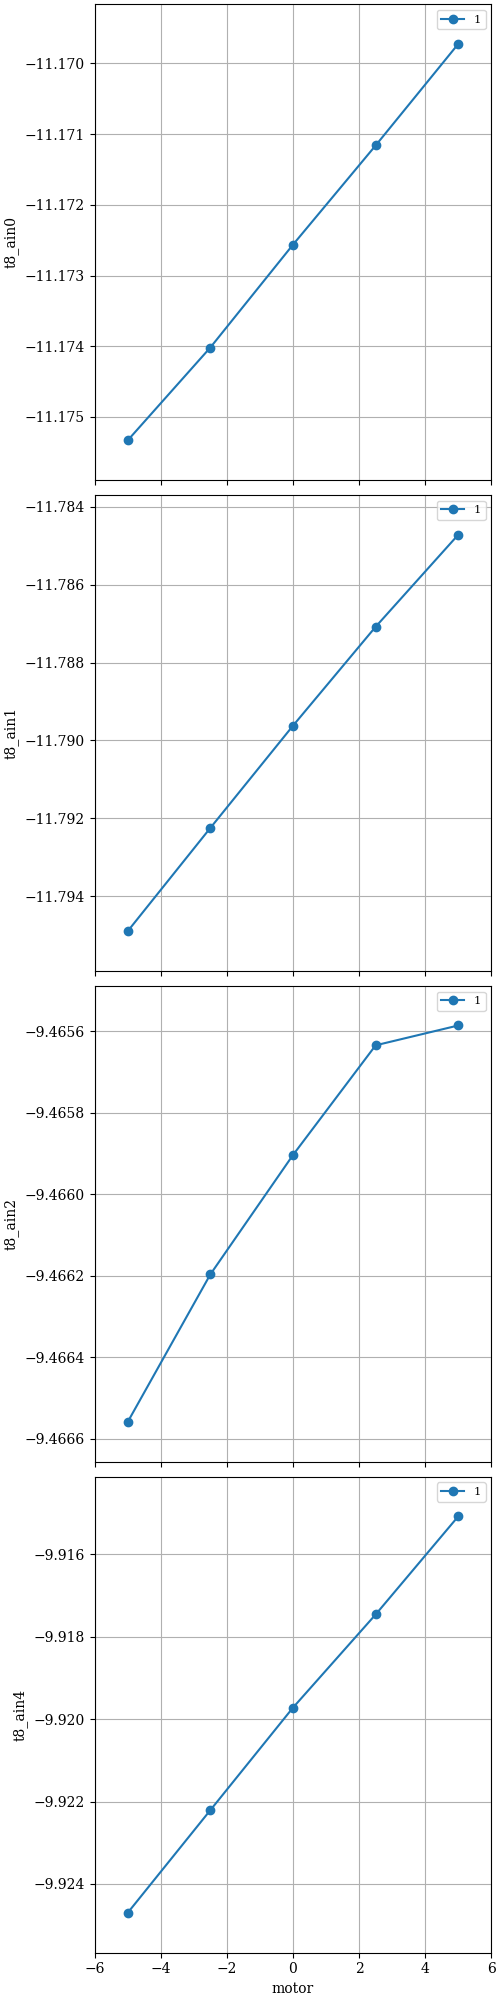

In [17]:
# Main Bluesky Scan
try:
    print("[ACQUISITION] Acquisition STARTED...")
    # run a scan and capture uid
    (uid,) = RE(scan([t8], motor, -5, 5, 5))  # type: ignore # blocks until complete

    print("[ACQUISITION] Acquisition FINISHED. uid:", uid)
    plt.show(block=False)
except Exception as e:
    print(f"[ERROR] Error during scan execution: {e}")
    print("***STOPPING EXECUTION*** Please check the error message and try again.")
    exit(1)

print("[VISUALIZATION] Close plot to proceed (block=True)...")
plt.show(block=False)

In [18]:
# %% Read back from Tiled
print("[DATASERVER] Retrieving run data from Tiled catalog...")

uid_list = tiled_client.keys()

for i, key in enumerate(uid_list):
    print(f"[DATASERVER] key {i}: {tiled_client[key]}")


print("[DATASERVER] Retrieving dataset from Tiled client...")
ds = tiled_client[uid_list[-1]]  # get the most recent dataset
# ds = tiled_client[key_list[-1]]  # get a past dataset
print("[DATASERVER] LOADED:", ds)

print("[DATASERVER] END DATA RETRIEVAL, BEGINNING POST-PROCESSING")

[DATASERVER] Retrieving run data from Tiled catalog...
[DATASERVER] key 0: <BlueskyRun v3.0 streams: {'primary'} scan_id=1 uid='d7e8359d' 2026-04-06 17:09>
[DATASERVER] Retrieving dataset from Tiled client...
[DATASERVER] LOADED: <BlueskyRun v3.0 streams: {'primary'} scan_id=1 uid='d7e8359d' 2026-04-06 17:09>
[DATASERVER] END DATA RETRIEVAL, BEGINNING POST-PROCESSING


# Post Processing

In [19]:
# Inspecting dataset variables
print("[POSTPROCESSING] Inspecting dataset variables...")

stream = ds.primary  # the primary stream is where the TiledWriter writes the data by default, but you can also access other streams if you have them configured (e.g. for metadata, or separate streams for different devices)

ds_xr = stream.read()  # xarray.Dataset containing all the data for this run
# ds_xr is a xarray.Dataset. It is faster to access values because stream will run a yield for each request, while ds_xr has all data in memory. However, ds_xr is not lazy and will load everything into memory at once, so it may not be suitable for very large datasets.
# For large dataset, use stream[key].read() to read one variable at a time, which will yield one event at a time and not load everything into memory at once.

[POSTPROCESSING] Inspecting dataset variables...


In [20]:
# %% I FOUND A BUG

# This works, returning a np array of floats
foo = stream["t8_ain1_waveform"].read()

# This does not work, returning a np array of strings instead of floats, which is not what we want
bar = stream.read()["t8_ain1_waveform"]

In [21]:
# %% Inspecting the dataset variables and their types/shapes to prepare for plotting and analysis
print("[POSTPROCESSING] Getting stream data into a pandas df")

# Prepare a dictionary to hold the data for each key
data = {}
waveform_cols = []
# Loop through each key and read the data
for key in stream.keys():
    arr = stream[key].read()
    # If the data is a 2D array (e.g., waveform: shape (events, waveform_length)), flatten or keep as list
    print(f"  Reading data for key: {key}, type: {type(arr)}, shape: {arr.shape}")
    if isinstance(arr, np.ndarray) and arr.ndim > 1:
        # Store as list of arrays (or you can flatten, or keep as is for further processing)
        data[key] = [a for a in arr]
        waveform_cols.append(key)
    else:
        # Scalar or 1D array
        data[key] = arr

[POSTPROCESSING] Getting stream data into a pandas df
  Reading data for key: seq_num, type: <class 'numpy.ndarray'>, shape: (5,)
  Reading data for key: time, type: <class 'numpy.ndarray'>, shape: (5,)
  Reading data for key: t8_ain0, type: <class 'numpy.ndarray'>, shape: (5,)
  Reading data for key: t8_ain1, type: <class 'numpy.ndarray'>, shape: (5,)
  Reading data for key: t8_ain2, type: <class 'numpy.ndarray'>, shape: (5,)
  Reading data for key: t8_ain4, type: <class 'numpy.ndarray'>, shape: (5,)
  Reading data for key: t8_ain0_waveform, type: <class 'numpy.ndarray'>, shape: (5, 1000)
  Reading data for key: t8_ain1_waveform, type: <class 'numpy.ndarray'>, shape: (5, 1000)
  Reading data for key: t8_ain2_waveform, type: <class 'numpy.ndarray'>, shape: (5, 1000)
  Reading data for key: t8_ain4_waveform, type: <class 'numpy.ndarray'>, shape: (5, 1000)
  Reading data for key: t8_waveform_time, type: <class 'numpy.ndarray'>, shape: (5, 1000)
  Reading data for key: motor, type: <class

In [22]:
# %% Create a Pandas DataFrame
df = pd.DataFrame(data)
df = df.explode(
    waveform_cols
)  # Needed to explode the waveform columns to get one row per event, with the waveform data as a list/array in each row

In [23]:
# %% Adjustments to time columns and indexing
time_cols = [col for col in df.columns if "ts_" in col or "_tim" in col]

print("[POSTPROCESSING] Adjusting time columns and DataFrame index...")
# If the index is still int64, try setting it to the time column
if df.index.dtype == "int64":
    df.index = pd.to_datetime(df["t8_waveform_time"], unit="s")
    df.index.name = "Time and Date"

print("[POSTPROCESSING] DataFrame index set to time column. Index dtype:", df.index.dtype)
# Remove time offset
df[time_cols] = df[time_cols] - (df[time_cols].min()).min()

print("[POSTPROCESSING] END OF POST-PROCESSING. DataFrame ready for analysis and visualization.")
print("[RESULT] DataFrame Columns:\n", df.columns)
print("[RESULT] DataFrame head:\n", df.head())

[POSTPROCESSING] Adjusting time columns and DataFrame index...
[POSTPROCESSING] DataFrame index set to time column. Index dtype: datetime64[ns]
[POSTPROCESSING] END OF POST-PROCESSING. DataFrame ready for analysis and visualization.
[RESULT] DataFrame Columns:
 Index(['seq_num', 'time', 't8_ain0', 't8_ain1', 't8_ain2', 't8_ain4',
       't8_ain0_waveform', 't8_ain1_waveform', 't8_ain2_waveform',
       't8_ain4_waveform', 't8_waveform_time', 'motor', 'motor_setpoint',
       'ts_t8_ain0', 'ts_t8_ain1', 'ts_t8_ain2', 'ts_t8_ain4',
       'ts_t8_ain0_waveform', 'ts_t8_ain1_waveform', 'ts_t8_ain2_waveform',
       'ts_t8_ain4_waveform', 'ts_t8_waveform_time', 'ts_motor',
       'ts_motor_setpoint'],
      dtype='str')
[RESULT] DataFrame head:
                                seq_num          time    t8_ain0    t8_ain1  \
Time and Date                                                                
2026-04-07 00:09:07.533317088        1  1.775521e+09 -11.175332 -11.794903   
2026-04-07 00:0

## Plots and Visualization

In [24]:
# Plot the data using Plotly. All sequence numbers will be plotted on the same figure. Each waveform column will be plotted as a separate curve, with markers for the data points and lines connecting them.
plotly_fig = go.Figure(layout=custom_layout("xdata [a.u.]", "ydata [a.u.]", "Plot Pandas"))
# plotly_fig = go.Figure()
color_cycle = itertools.cycle(colors_plotly)

for _i in df["seq_num"].unique()[0:1]:
    print(f"seq_num {_i} has {len(df[df['seq_num'] == _i])} events")

    _x_vec = df[df["seq_num"] == _i]["t8_waveform_time"]

    _x_vec -= _x_vec.min()  # remove time offset for better visualization

    for col in waveform_cols:
        print(f"Plotting {col} for seq_num {_i}")
        _y_vec = df[df["seq_num"] == _i][col]
        _color = next(color_cycle)
        plotly_fig.add_scatter(
            x=_x_vec,
            y=_y_vec,
            mode="lines+markers",  # Use lines and markers for the second curve
            name=f"{col} for seq_num {_i}",  # Legend label for the second curve
            marker=dict(symbol="x", color=_color),
            line=dict(color=_color.replace("rgb", "rgba").replace(")", ",0.5)")),  # Line with alpha
        )


# Show the figure
plotly_fig.show()
print("[VISUALIZATION] Plotting complete.")

if save_plot:
    plotly_fig.write_html(
        get_unique_fname("Results\\interactive_plot", "html"), include_mathjax="cdn"
    )  # include_mathjax='cdn' needed for Latex in html files
    plotly_fig.write_image(get_unique_fname("Results\\interactive_plot", "svg"), scale=1.0)

seq_num 1 has 1000 events
Plotting t8_ain0_waveform for seq_num 1
Plotting t8_ain1_waveform for seq_num 1
Plotting t8_ain2_waveform for seq_num 1
Plotting t8_ain4_waveform for seq_num 1
Plotting t8_waveform_time for seq_num 1


[VISUALIZATION] Plotting complete.


In [25]:
# Plot each waveform column separately, with all sequence numbers on the same figure
color_cycle = itertools.cycle(colors_plotly)

for _i, col in enumerate(waveform_cols):
    plotly_fig = go.Figure(layout=custom_layout("xdata [a.u.]", "ydata [a.u.]", "Plot Pandas"))
    _x_vec = df["t8_waveform_time"]

    print(f"Plotting {col}...")
    _y_vec = df[col]
    _color = next(color_cycle)
    plotly_fig.add_scatter(
        x=_x_vec,
        y=_y_vec,
        mode="lines+markers",  # Use lines and markers for the second curve
        name=f"{col}",  # Legend label for the second curve
        marker=dict(symbol="x", color=_color),
        line=dict(color=_color.replace("rgb", "rgba").replace(")", ",0.5)")),  # Line with alpha
    )

    # Show the figure
    plotly_fig.show()
    if save_plot:
        plotly_fig.write_html(
            get_unique_fname("Results\\interactive_plot", "html"), include_mathjax="cdn"
        )  # include_mathjax='cdn' needed for Latex in html files
        plotly_fig.write_image(get_unique_fname("Results\\interactive_plot", "svg"), scale=1.0)

Plotting t8_ain0_waveform...


Plotting t8_ain1_waveform...


Plotting t8_ain2_waveform...


Plotting t8_ain4_waveform...


Plotting t8_waveform_time...


# END - Close connections

In [26]:
if close_connections_at_end:
    print("[INFO] END OF SCRIPT. Closing LabJack T8 connection...")
    if t8 is not None:
        t8.close()
    print("[INFO] LabJack T8 connection closed.")

    print("[INFO] Closing Tiled server connection...")
    if tiled_server is not None:
        tiled_server.close()  # or tiled_server.shutdown() if available
    print("[INFO] Tiled server connection closed.")
else:
    print("[INFO] END OF SCRIPT. ATTENTION: Connections are still OPEN.\n *** Please close them manually if needed ***")

[INFO] END OF SCRIPT. ATTENTION: Connections are still OPEN.
 *** Please close them manually if needed ***
